### parameter estimation with `cogwheel`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from cogwheel import cosmology, data, posterior, sampling, gw_plotting, gw_utils

import lal
import gwosc
from gwpy.table import EventTable

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/Users/abbywilliams/Research/Chicago/GW/code')
from parameter_estimation import run_parameter_estimation, get_event_data

/Users/abbywilliams/Research/venv/gwaves/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### get event data

In [3]:
eventname = 'GW150914'

In [4]:
# get the event timeseries data using cogwheel
event_data = get_event_data(eventname)

Skipping existing file /Users/abbywilliams/Research/venv/gwaves/lib/python3.9/site-packages/cogwheel/data/gwosc_files/GW150914/H_GW150914.hdf5
Skipping existing file /Users/abbywilliams/Research/venv/gwaves/lib/python3.9/site-packages/cogwheel/data/gwosc_files/GW150914/L_GW150914.hdf5


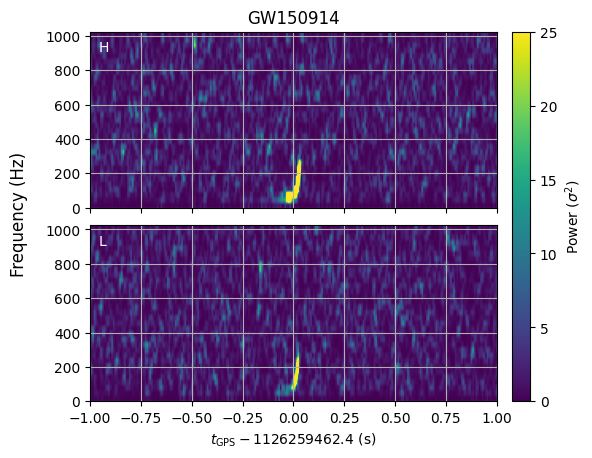

In [5]:
# what does the spectrogram look like?
event_data.specgram(xlim=(-1,1))

In [7]:
# now we want to look up the chirp mass:
catalog = 'GWTC-1-confident'
events = EventTable.fetch_open_data(catalog,
                                   columns=["name", "chirp_mass_source", "chirp_mass"])
idx = [eventname in x for x in events['name']]
event = events[idx]
assert len(event) == 1, f"{len(event)} events found for {eventname}; please refine eventname"

In [8]:
event['chirp_mass']

None


In [9]:
# hmm the chirp mass is None. what are the other events like?
events

name,chirp_mass_source,chirp_mass
,solMass,
str11,float64,object
GW170823-v1,29.2,None
GW170818-v1,26.5,None
GW170817-v3,1.186,None
GW170814-v3,24.1,None
GW170809-v1,24.9,None
GW170729-v1,35.4,None
GW170608-v3,7.9,None
GW170104-v2,21.4,None


In [10]:
# why are all the chirp masses None ? I checked on GWOSC that actual chirp masses are listed there

In [22]:
whitened_td = event_data.get_whitened_td()

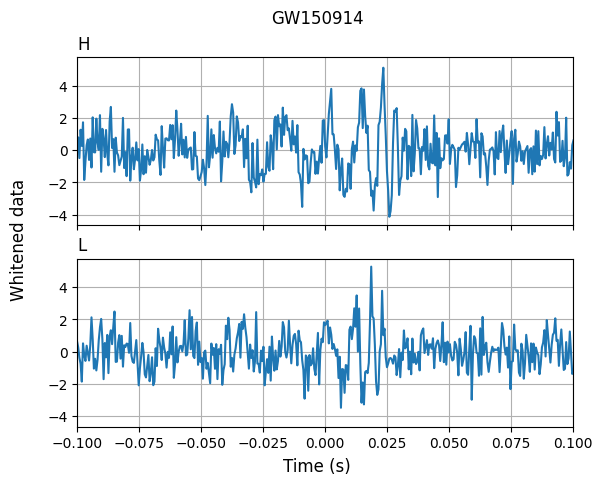

In [23]:
fig, axs = plt.subplots(len(event_data.detector_names), sharex=True, sharey=True)
for det_name, ax, wht_strain in zip(event_data.detector_names, axs, whitened_td):
    ax.plot(event_data.times - event_data.tcoarse, wht_strain)
    ax.grid()
    ax.set_title(det_name, loc='left')

ax.set_xlim(-0.1, 0.1)
fig.supxlabel('Time (s)')
fig.supylabel('Whitened data')
fig.suptitle(event_data.eventname);

In [24]:
# chirp mass (from the properties paper, PhysRevLett.116.241102)
mchirp_guess = 30
# guess the merger time (how can I do this without looking at the waveform and estimating by eye?)
t_merger_guess = 0.02

In [25]:
# run parameter estimation and return the samples from the posterior
samples = run_parameter_estimation(eventname, t_merger_guess, mchirp_guess)

Skipping existing file /Users/abbywilliams/Research/venv/gwaves/lib/python3.9/site-packages/cogwheel/data/gwosc_files/GW150914/H_GW150914.hdf5
Skipping existing file /Users/abbywilliams/Research/venv/gwaves/lib/python3.9/site-packages/cogwheel/data/gwosc_files/GW150914/L_GW150914.hdf5

computing posterior...
Searching incoherent solution for GW150914
Set intrinsic parameters, lnL = 290.7896578877875
Set time, lnL(H) = 198.9062205015718
Set sky location, lnL = 290.8269318493388
Set phase and distance, lnL = 290.8269318493388
Set mchirp_range = (19.405361358820862, 109.76086701623943)

sampling from posterior...
rundir: pe_runs/IntrinsicAlignedSpinIASPrior/GW150914/run_1
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 20     | 1        | 4        | 24500    | N/A    | 6889  | +261.20  


In [26]:
samples

,mchirp,lnq,chieff,cumchidiff,weights,m1,m2,s1z,s2z,l1,...,phi_ref,psi,iota,t_geocenter,lnl_marginalized,lnl,h_h,n_effective,n_qmc,ra
0,84.977020,-1.907479,0.196644,0.784655,2.813823e-104,274.390345,40.734385,0.310353,-0.569309,0.0,...,4.402815,1.792208,0.327926,-0.064908,36.359378,54.097851,101.855320,32.565196,2048,2.228258
1,22.123690,-1.926112,0.454172,0.365983,7.854282e-97,72.205899,10.521383,0.481294,0.268035,0.0,...,3.845898,2.314296,0.566479,0.021820,54.846949,79.694873,145.269020,17.766640,2048,0.992822
2,28.646554,-1.345509,0.558525,0.916460,2.663709e-98,67.264011,17.516034,0.920868,-0.832921,0.0,...,1.162874,1.294452,2.553263,0.008379,51.282598,73.816709,141.003410,11.828558,2048,1.674366
3,90.636767,-1.145196,-0.501996,0.748846,1.254102e-100,190.418641,60.583904,-0.503364,-0.497693,0.0,...,3.562238,1.504119,1.311454,-0.055101,44.794443,64.199145,104.972496,21.666227,2048,2.154120
4,67.772757,-1.622944,-0.058668,0.139816,8.096073e-99,186.036533,36.708177,-0.212385,0.720367,0.0,...,5.092819,1.297463,2.714757,-0.050509,49.195599,67.703147,101.372316,6.984596,2048,2.878014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24495,31.317947,-0.172556,-0.028788,0.868548,8.640065e-06,39.245718,33.025701,0.567261,-0.737096,0.0,...,0.896384,3.021605,2.133594,0.007968,278.609365,306.125699,599.791063,74.267707,4096,2.199564
24496,31.437156,-0.090456,-0.013490,0.824348,7.349061e-06,37.790302,34.521984,0.566779,-0.648697,0.0,...,1.676988,0.678775,2.594737,0.007429,278.444806,308.994433,664.048525,80.942654,4096,2.268271
24497,31.583551,-0.105731,-0.005757,0.960002,7.984400e-06,38.260215,34.421448,0.816760,-0.920004,0.0,...,3.575132,2.385670,1.948315,0.006613,278.522928,309.554899,616.993294,78.615909,4096,2.433398
24498,31.677758,-0.261006,-0.013854,0.950929,7.649348e-06,41.531222,31.990517,0.670154,-0.901858,0.0,...,1.919855,2.135725,2.162412,0.015057,278.474242,308.666285,626.808202,92.252389,4096,0.988735


In [27]:
plot_params = [
    # 'mchirp',
    # 'lnq',
    # 'chieff',
    # 'cumchidiff',
    # 'weights',
    'm1',
    'm2',
    's1z',
    's2z',
    # 'l1',
    # 'l2',
    # 'f_ref',
    'd_luminosity',
    'ra',
    'dec',
    # 'lon',
    'phi_ref',
    'psi',
    'iota',
    't_geocenter',
    # 'lnl_marginalized',
    'lnl',
    # 'h_h',
    # 'n_effective',
    # 'n_qmc',
]

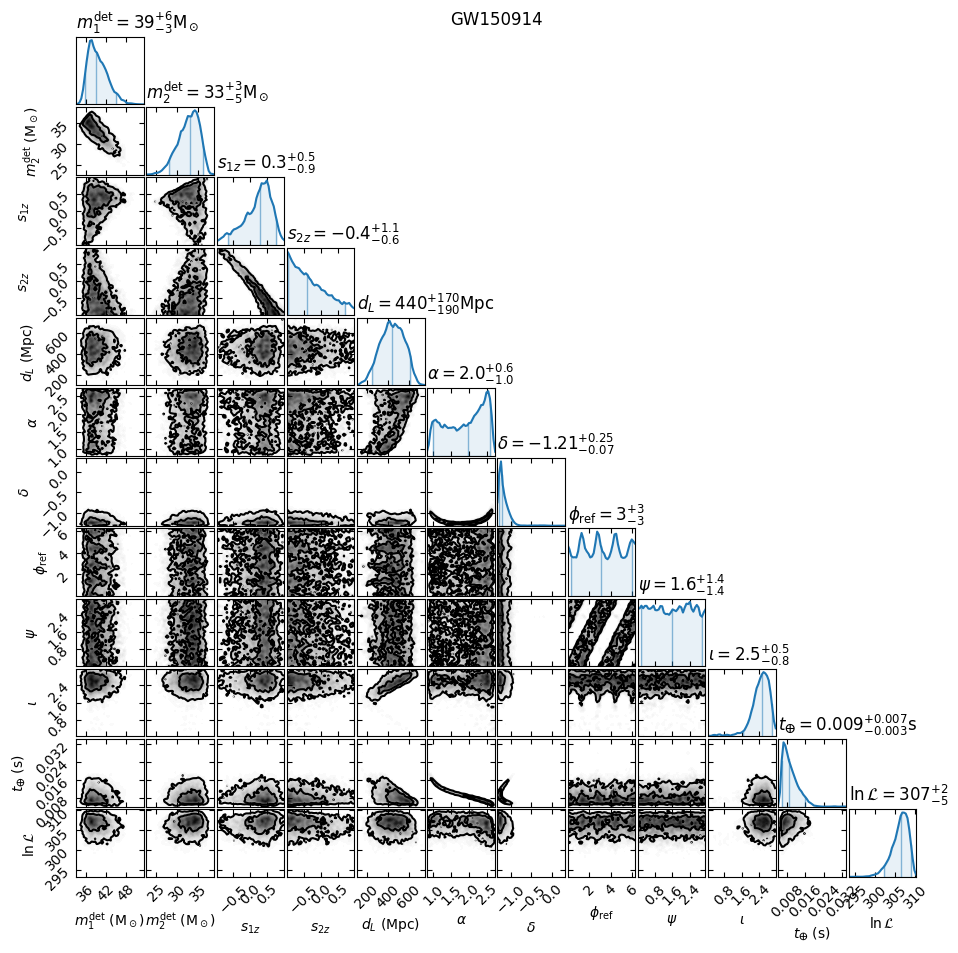

In [28]:
# note that cogwheel.gw_plotting.CornerPlot understands the weights automatically
corner_plot = cogwheel.gw_plotting.CornerPlot(
    samples, params=plot_params, tail_probability=1e-4
)
corner_plot.plot(title=event_data.eventname)